# Linear Algebra for Machine Learning

## Why Linear Algebra?

Linear algebra is the language of machine learning. Every neural network weight matrix, every embedding vector, every PCA transformation all of it is linear algebra. Without it, you cannot truly understand *why* algorithms work.

**Historical context:** Linear algebra was formalized in the 19th century by mathematicians like Cayley and Hamilton. Today it underpins virtually all of modern AI.

---

## Table of Contents
1. Scalars, Vectors, Matrices, Tensors
2. Basic Operations
3. Dot Product & Matrix Multiplication
4. Transpose, Inverse, Determinant
5. Rank, Trace, Norms
6. Eigenvalues & Eigenvectors
7. Singular Value Decomposition (SVD)
8. PCA Derivation
9. Orthogonality, Span, Basis
10. Applications in ML

## 1. Scalars, Vectors, Matrices, Tensors

| Object | Definition | Example |
|--------|-----------|--------|
| **Scalar** | Single number | $x = 5$ |
| **Vector** | 1D array of numbers | $\mathbf{v} = [1, 2, 3]^T \in \mathbb{R}^3$ |
| **Matrix** | 2D array | $A \in \mathbb{R}^{m \times n}$ |
| **Tensor** | N-dimensional array | $T \in \mathbb{R}^{d_1 \times d_2 \times \cdots \times d_n}$ |

A column vector:
$$\mathbf{v} = \begin{bmatrix} v_1 \\ v_2 \\ \vdots \\ v_n \end{bmatrix} \in \mathbb{R}^n$$

A matrix:
$$A = \begin{bmatrix} a_{11} & a_{12} & \cdots & a_{1n} \\ a_{21} & a_{22} & \cdots & a_{2n} \\ \vdots & \vdots & \ddots & \vdots \\ a_{m1} & a_{m2} & \cdots & a_{mn} \end{bmatrix} \in \mathbb{R}^{m \times n}$$

In [1]:
import numpy as np

# Scalar
scalar = 5.0
print(f"Scalar: {scalar}, type: {type(scalar)}")

# Vector
v = np.array([1, 2, 3])          # row vector shape (3,)
v_col = np.array([[1],[2],[3]])   # column vector shape (3,1)
print(f"Vector: {v}, shape: {v.shape}")

# Matrix
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])
print(f"Matrix shape: {A.shape}\n{A}")

# Tensor (3D)
T = np.random.randn(2, 3, 4)     # batch x height x width
print(f"Tensor shape: {T.shape}")

Scalar: 5.0, type: <class 'float'>
Vector: [1 2 3], shape: (3,)
Matrix shape: (3, 3)
[[1 2 3]
 [4 5 6]
 [7 8 9]]
Tensor shape: (2, 3, 4)


## 2. Basic Operations

### Vector Addition
$$\mathbf{u} + \mathbf{v} = \begin{bmatrix} u_1 + v_1 \\ u_2 + v_2 \\ \vdots \end{bmatrix}$$

### Scalar Multiplication
$$c \cdot \mathbf{v} = \begin{bmatrix} c v_1 \\ c v_2 \\ \vdots \end{bmatrix}$$

### Element-wise (Hadamard) Product
$$A \odot B = \begin{bmatrix} a_{11}b_{11} & \cdots \\ \vdots & \ddots \end{bmatrix}$$

In [2]:
u = np.array([1, 2, 3])
v = np.array([4, 5, 6])

print("Vector addition:", u + v)
print("Scalar mult:", 3 * u)
print("Element-wise product:", u * v)

A = np.array([[1,2],[3,4]])
B = np.array([[5,6],[7,8]])
print("Matrix addition:\n", A + B)
print("Hadamard product:\n", A * B)

Vector addition: [5 7 9]
Scalar mult: [3 6 9]
Element-wise product: [ 4 10 18]
Matrix addition:
 [[ 6  8]
 [10 12]]
Hadamard product:
 [[ 5 12]
 [21 32]]


## 3. Dot Product & Matrix Multiplication

### Dot Product
$$\mathbf{u} \cdot \mathbf{v} = \sum_{i=1}^n u_i v_i = \|\mathbf{u}\| \|\mathbf{v}\| \cos\theta$$

Geometric meaning: measures how much two vectors point in the same direction.

### Matrix Multiplication
For $A \in \mathbb{R}^{m \times k}$ and $B \in \mathbb{R}^{k \times n}$:
$$(AB)_{ij} = \sum_{l=1}^k A_{il} B_{lj}$$

Result: $C \in \mathbb{R}^{m \times n}$

**Properties:**
- Associative: $(AB)C = A(BC)$
- Distributive: $A(B+C) = AB + AC$
- **NOT** commutative: $AB \neq BA$ in general
- $(AB)^T = B^T A^T$

**In ML:** A forward pass through a linear layer is $\mathbf{y} = W\mathbf{x} + \mathbf{b}$ pure matrix-vector multiplication.

In [3]:
u = np.array([1, 2, 3])
v = np.array([4, 5, 6])

# Dot product
dot = np.dot(u, v)
dot2 = u @ v
print(f"Dot product: {dot}")  # 1*4 + 2*5 + 3*6 = 32

# Cosine similarity
cos_sim = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
print(f"Cosine similarity: {cos_sim:.4f}")

# Matrix multiplication
A = np.array([[1,2,3],[4,5,6]])   # 2x3
B = np.array([[7,8],[9,10],[11,12]])  # 3x2
C = A @ B   # 2x2
print(f"A @ B:\n{C}")

# Neural network forward pass simulation
W = np.random.randn(4, 3)   # weight matrix
x = np.random.randn(3)      # input vector
b = np.zeros(4)             # bias
y = W @ x + b               # linear layer
print(f"Linear layer output shape: {y.shape}")

Dot product: 32
Cosine similarity: 0.9746
A @ B:
[[ 58  64]
 [139 154]]
Linear layer output shape: (4,)


## 4. Transpose, Inverse, Determinant

### Transpose
$$(A^T)_{ij} = A_{ji}$$

Properties: $(A^T)^T = A$, $(AB)^T = B^T A^T$, $(A+B)^T = A^T + B^T$

### Inverse
For square matrix $A$, the inverse $A^{-1}$ satisfies:
$$A A^{-1} = A^{-1} A = I$$

A matrix is invertible iff $\det(A) \neq 0$.

For $2 \times 2$:
$$A = \begin{bmatrix} a & b \\ c & d \end{bmatrix}, \quad A^{-1} = \frac{1}{ad-bc}\begin{bmatrix} d & -b \\ -c & a \end{bmatrix}$$

### Determinant
For $2 \times 2$: $\det(A) = ad - bc$

For $3 \times 3$ (cofactor expansion):
$$\det(A) = a_{11}(a_{22}a_{33} - a_{23}a_{32}) - a_{12}(a_{21}a_{33} - a_{23}a_{31}) + a_{13}(a_{21}a_{32} - a_{22}a_{31})$$

**Geometric meaning:** The determinant measures the volume scaling factor of the linear transformation.

In [4]:
A = np.array([[1., 2.], [3., 4.]])

# Transpose
print("Transpose:\n", A.T)

# Determinant
det = np.linalg.det(A)
print(f"Determinant: {det:.4f}")  # 1*4 - 2*3 = -2

# Inverse
A_inv = np.linalg.inv(A)
print("Inverse:\n", A_inv)
print("A @ A_inv (should be I):\n", np.round(A @ A_inv, 10))

# Solving linear systems: Ax = b
b = np.array([5., 11.])
x = np.linalg.solve(A, b)  # Better than inv(A) @ b
print(f"Solution x: {x}")
print(f"Verification A @ x: {A @ x}")

Transpose:
 [[1. 3.]
 [2. 4.]]
Determinant: -2.0000
Inverse:
 [[-2.   1. ]
 [ 1.5 -0.5]]
A @ A_inv (should be I):
 [[1. 0.]
 [0. 1.]]
Solution x: [1. 2.]
Verification A @ x: [ 5. 11.]


## 5. Rank, Trace, and Norms

### Rank
The **rank** of a matrix is the number of linearly independent rows (or columns).
$$\text{rank}(A) \leq \min(m, n)$$
A matrix is **full rank** if $\text{rank}(A) = \min(m,n)$.

### Trace
$$\text{tr}(A) = \sum_{i=1}^n a_{ii}$$
Properties: $\text{tr}(AB) = \text{tr}(BA)$, $\text{tr}(A) = \sum_i \lambda_i$

### Vector Norms
**L1 norm (Manhattan):**
$$\|\mathbf{v}\|_1 = \sum_{i=1}^n |v_i|$$

**L2 norm (Euclidean):**
$$\|\mathbf{v}\|_2 = \sqrt{\sum_{i=1}^n v_i^2}$$

**Lp norm:**
$$\|\mathbf{v}\|_p = \left(\sum_{i=1}^n |v_i|^p\right)^{1/p}$$

**L∞ norm:**
$$\|\mathbf{v}\|_\infty = \max_i |v_i|$$

### Matrix Norms
**Frobenius norm:**
$$\|A\|_F = \sqrt{\sum_{i,j} a_{ij}^2} = \sqrt{\text{tr}(A^T A)}$$

**In ML:** L1 norm → Lasso regularization, L2 norm → Ridge regularization

In [5]:
A = np.array([[1, 2, 3],[4, 5, 6],[7, 8, 9]], dtype=float)
v = np.array([3., -4., 0.])

# Rank
print(f"Rank of A: {np.linalg.matrix_rank(A)}")  # Rank 2 (row 3 = row1+row2)

# Trace
print(f"Trace of A: {np.trace(A)}")  # 1+5+9=15

# Norms
print(f"L1 norm: {np.linalg.norm(v, 1)}")    # 7
print(f"L2 norm: {np.linalg.norm(v, 2)}")    # 5
print(f"Linf norm: {np.linalg.norm(v, np.inf)}")  # 4

# Frobenius norm
B = np.array([[1.,2.],[3.,4.]])
print(f"Frobenius norm: {np.linalg.norm(B, 'fro'):.4f}")

Rank of A: 2
Trace of A: 15.0
L1 norm: 7.0
L2 norm: 5.0
Linf norm: 4.0
Frobenius norm: 5.4772


## 6. Eigenvalues & Eigenvectors

### Definition
For a square matrix $A$, a non-zero vector $\mathbf{v}$ is an **eigenvector** with **eigenvalue** $\lambda$ if:
$$A\mathbf{v} = \lambda \mathbf{v}$$

**Intuition:** Eigenvectors are the *special directions* that only get scaled (not rotated) by the transformation $A$.

### Finding Eigenvalues
From $A\mathbf{v} = \lambda\mathbf{v}$:
$$(A - \lambda I)\mathbf{v} = 0$$

For non-trivial solutions, we need:
$$\det(A - \lambda I) = 0 \quad \text{(characteristic equation)}$$

### Eigendecomposition
If $A$ has $n$ linearly independent eigenvectors:
$$A = Q \Lambda Q^{-1}$$
where $Q$ is the matrix of eigenvectors (columns), and $\Lambda = \text{diag}(\lambda_1, \ldots, \lambda_n)$.

For symmetric matrices: $A = Q \Lambda Q^T$ (eigenvectors are orthonormal).

### Key Properties
- $\text{tr}(A) = \sum_i \lambda_i$
- $\det(A) = \prod_i \lambda_i$
- Symmetric matrices always have real eigenvalues
- Positive definite matrix: all eigenvalues $> 0$

**In ML:** Covariance matrix eigendecomposition → PCA. Hessian eigenvalues → curvature of loss landscape.

In [6]:
import numpy as np

# Symmetric matrix (real eigenvalues guaranteed)
A = np.array([[4., 2.],
              [2., 3.]])

eigenvalues, eigenvectors = np.linalg.eigh(A)  # eigh for symmetric
print("Eigenvalues:", eigenvalues)
print("Eigenvectors (columns):\n", eigenvectors)

# Verify: A @ v = lambda * v
for i in range(len(eigenvalues)):
    lam = eigenvalues[i]
    v = eigenvectors[:, i]
    print(f"\nlambda={lam:.4f}: A@v={A@v}, lambda*v={lam*v}")
    print(f"  Match: {np.allclose(A @ v, lam * v)}")

# Eigendecomposition reconstruction
Q = eigenvectors
Lambda = np.diag(eigenvalues)
A_reconstructed = Q @ Lambda @ Q.T
print("\nReconstruction matches:", np.allclose(A, A_reconstructed))

# Properties
print(f"\nTrace = {np.trace(A):.4f}, Sum of eigenvalues = {sum(eigenvalues):.4f}")
print(f"Det = {np.linalg.det(A):.4f}, Product of eigenvalues = {np.prod(eigenvalues):.4f}")

Eigenvalues: [1.43844719 5.56155281]
Eigenvectors (columns):
 [[ 0.61541221 -0.78820544]
 [-0.78820544 -0.61541221]]

lambda=1.4384: A@v=[ 0.88523796 -1.1337919 ], lambda*v=[ 0.88523796 -1.1337919 ]
  Match: True

lambda=5.5616: A@v=[-4.38364617 -3.4226475 ], lambda*v=[-4.38364617 -3.4226475 ]
  Match: True

Reconstruction matches: True

Trace = 7.0000, Sum of eigenvalues = 7.0000
Det = 8.0000, Product of eigenvalues = 8.0000


## 7. Singular Value Decomposition (SVD)

### Definition
Any matrix $A \in \mathbb{R}^{m \times n}$ can be decomposed as:
$$A = U \Sigma V^T$$

Where:
- $U \in \mathbb{R}^{m \times m}$: Left singular vectors (orthonormal columns), eigenvectors of $AA^T$
- $\Sigma \in \mathbb{R}^{m \times n}$: Diagonal matrix of singular values $\sigma_1 \geq \sigma_2 \geq \cdots \geq 0$
- $V \in \mathbb{R}^{n \times n}$: Right singular vectors (orthonormal columns), eigenvectors of $A^T A$

### Relationship to Eigendecomposition
$$\sigma_i = \sqrt{\lambda_i(A^T A)}$$

### Truncated SVD (Low-Rank Approximation)
Keep only the top $k$ singular values:
$$A \approx A_k = U_k \Sigma_k V_k^T = \sum_{i=1}^k \sigma_i \mathbf{u}_i \mathbf{v}_i^T$$

**Eckart-Young theorem:** $A_k$ is the best rank-$k$ approximation of $A$ in the Frobenius norm:
$$\|A - A_k\|_F = \sqrt{\sum_{i=k+1}^r \sigma_i^2}$$

### Applications in ML
- **Dimensionality reduction** (PCA uses SVD)
- **Recommender systems** (matrix factorization)
- **NLP** (Latent Semantic Analysis)
- **Image compression**
- **Pseudo-inverse**: $A^+ = V \Sigma^+ U^T$

A shape: (4, 3)
U shape: (4, 4), singular values: [2.37642759 0.91384752 0.81326001], Vt shape: (3, 3)
Reconstruction error: 8.01e-16



Image singular values: [48.307845   24.95585264  8.02075326  6.02937301  3.53447932  0.61576328
  0.          0.        ]


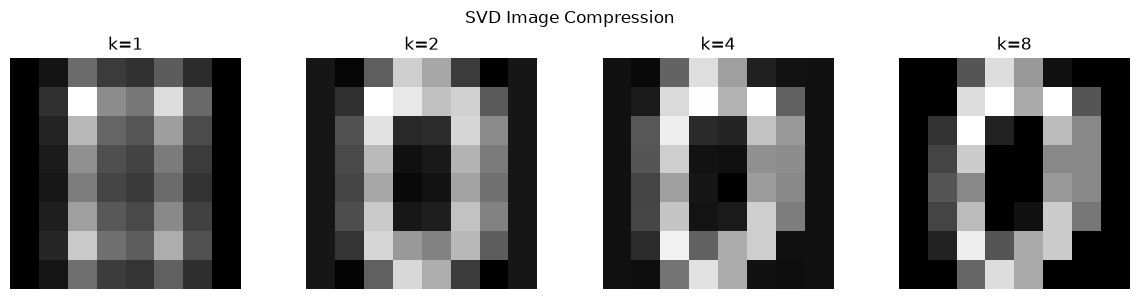


Pseudo-inverse shape: (2, 3)
A_pinv @ A:
[[ 1.  0.]
 [-0.  1.]]


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Create a sample matrix
np.random.seed(42)
A = np.random.randn(4, 3)

# Full SVD
U, s, Vt = np.linalg.svd(A, full_matrices=True)
print(f"A shape: {A.shape}")
print(f"U shape: {U.shape}, singular values: {s}, Vt shape: {Vt.shape}")

# Reconstruct A
Sigma = np.zeros(A.shape)
Sigma[:len(s), :len(s)] = np.diag(s)
A_reconstructed = U @ Sigma @ Vt
print(f"Reconstruction error: {np.linalg.norm(A - A_reconstructed):.2e}")

# Truncated SVD - image compression example
from sklearn.datasets import load_digits
digits = load_digits()
img = digits.images[0]  # 8x8

U, s, Vt = np.linalg.svd(img)
print(f"\nImage singular values: {s}")

# Low-rank approximations
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for idx, k in enumerate([1, 2, 4, 8]):
    img_k = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
    axes[idx].imshow(img_k, cmap='gray')
    axes[idx].set_title(f'k={k}')
    axes[idx].axis('off')
plt.suptitle('SVD Image Compression')
plt.tight_layout()
plt.show()

# Pseudo-inverse
A = np.array([[1.,2.],[3.,4.],[5.,6.]])
A_pinv = np.linalg.pinv(A)
print(f"\nPseudo-inverse shape: {A_pinv.shape}")
print(f"A_pinv @ A:\n{np.round(A_pinv @ A, 4)}")

## 8. Principal Component Analysis (PCA) Derivation

### Goal
Find a lower-dimensional subspace that preserves **maximum variance** in the data.

### Step-by-step Derivation

**Step 1: Center the data**
$$\tilde{X} = X - \mu, \quad \mu = \frac{1}{n}\sum_{i=1}^n \mathbf{x}_i$$

**Step 2: Compute the covariance matrix**
$$C = \frac{1}{n-1} \tilde{X}^T \tilde{X} \in \mathbb{R}^{d \times d}$$

**Step 3: Eigendecompose $C$**
$$C = Q \Lambda Q^T$$
where $\Lambda = \text{diag}(\lambda_1, \ldots, \lambda_d)$ with $\lambda_1 \geq \lambda_2 \geq \cdots$

**Step 4: Project onto top $k$ eigenvectors**
$$Z = \tilde{X} Q_k \in \mathbb{R}^{n \times k}$$

**Explained Variance Ratio:**
$$\text{EVR}_i = \frac{\lambda_i}{\sum_{j=1}^d \lambda_j}$$

**Connection to SVD:** PCA of $\tilde{X}$ is equivalent to SVD of $\tilde{X}$, where singular vectors = eigenvectors of $C$.

Explained variance ratios: [0.92461872 0.05306648 0.01710261 0.00521218]
Top 2 components explain: 97.8% of variance


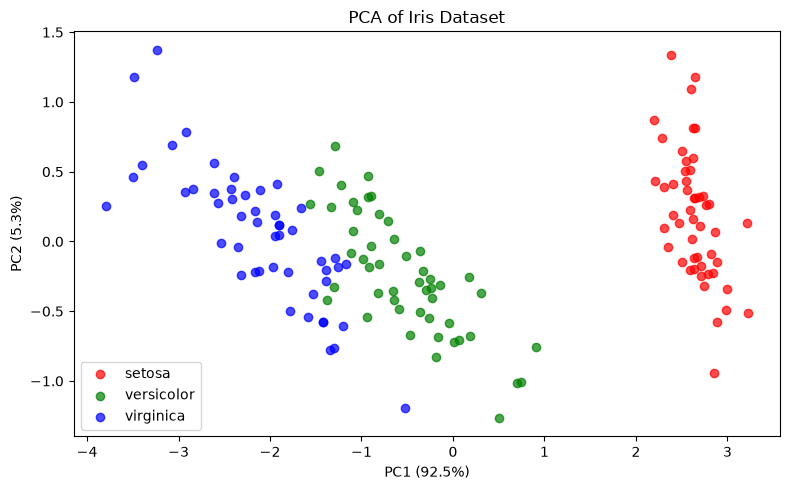

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

# Load Iris dataset
iris = load_iris()
X = iris.data  # 150 x 4
y = iris.target

# Manual PCA
X_centered = X - X.mean(axis=0)
C = (X_centered.T @ X_centered) / (len(X) - 1)
eigenvalues, eigenvectors = np.linalg.eigh(C)

# Sort descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Project to 2D
Z_manual = X_centered @ eigenvectors[:, :2]

# Sklearn PCA
pca = PCA(n_components=2)
Z_sklearn = pca.fit_transform(X)

# Explained variance
evr = eigenvalues / eigenvalues.sum()
print("Explained variance ratios:", evr)
print(f"Top 2 components explain: {evr[:2].sum()*100:.1f}% of variance")

# Visualize
colors = ['red', 'green', 'blue']
fig, ax = plt.subplots(figsize=(8, 5))
for i, cls in enumerate(iris.target_names):
    mask = y == i
    ax.scatter(Z_manual[mask, 0], Z_manual[mask, 1], c=colors[i], label=cls, alpha=0.7)
ax.set_xlabel(f'PC1 ({evr[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
ax.set_title('PCA of Iris Dataset')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Orthogonality, Span, Basis, Linear Independence

### Linear Independence
Vectors $\{\mathbf{v}_1, \ldots, \mathbf{v}_k\}$ are **linearly independent** if:
$$c_1 \mathbf{v}_1 + c_2 \mathbf{v}_2 + \cdots + c_k \mathbf{v}_k = \mathbf{0} \implies c_1 = c_2 = \cdots = c_k = 0$$

### Span
The **span** of vectors $\{\mathbf{v}_1, \ldots, \mathbf{v}_k\}$ is all linear combinations:
$$\text{span}(\mathbf{v}_1, \ldots, \mathbf{v}_k) = \left\{\sum_{i=1}^k c_i \mathbf{v}_i : c_i \in \mathbb{R}\right\}$$

### Basis
A **basis** of a vector space $V$ is a set of linearly independent vectors that span $V$.

The standard basis of $\mathbb{R}^n$: $\mathbf{e}_1=[1,0,\ldots,0]^T, \mathbf{e}_2=[0,1,\ldots,0]^T, \ldots$

### Orthogonality
Vectors $\mathbf{u}$ and $\mathbf{v}$ are **orthogonal** if:
$$\mathbf{u} \cdot \mathbf{v} = 0$$

A set of vectors is **orthonormal** if pairwise orthogonal and each has unit norm:
$$\mathbf{v}_i \cdot \mathbf{v}_j = \delta_{ij} = \begin{cases} 1 & i=j \\ 0 & i \neq j \end{cases}$$

### Gram-Schmidt Orthogonalization
Given linearly independent vectors $\{\mathbf{a}_1, \ldots, \mathbf{a}_k\}$, produce orthonormal set:
$$\mathbf{u}_1 = \mathbf{a}_1, \quad \mathbf{e}_1 = \frac{\mathbf{u}_1}{\|\mathbf{u}_1\|}$$
$$\mathbf{u}_k = \mathbf{a}_k - \sum_{j=1}^{k-1} \text{proj}_{\mathbf{e}_j}(\mathbf{a}_k), \quad \text{proj}_{\mathbf{e}}(\mathbf{a}) = (\mathbf{a}\cdot\mathbf{e})\mathbf{e}$$

In [9]:
import numpy as np

# Check orthogonality
u = np.array([1., 0.])
v = np.array([0., 1.])
print(f"u · v = {np.dot(u, v)} (orthogonal: {np.isclose(np.dot(u, v), 0)})")

# Gram-Schmidt
def gram_schmidt(vectors):
    basis = []
    for v in vectors:
        w = v.copy().astype(float)
        for b in basis:
            w -= np.dot(w, b) * b
        if np.linalg.norm(w) > 1e-10:
            basis.append(w / np.linalg.norm(w))
    return np.array(basis)

vecs = [np.array([1., 1., 0.]),
        np.array([1., 0., 1.]),
        np.array([0., 1., 1.])]

Q = gram_schmidt(vecs)
print("\nOrthonormal basis:")
for i, q in enumerate(Q):
    print(f"  q{i+1} = {q}")

# Verify orthonormality
print("\nQ @ Q.T (should be ~I):")
print(np.round(Q @ Q.T, 10))

# QR decomposition (built-in Gram-Schmidt)
A = np.column_stack(vecs)
Q_np, R = np.linalg.qr(A)
print(f"\nQR decomposition Q shape: {Q_np.shape}, R shape: {R.shape}")

u · v = 0.0 (orthogonal: True)

Orthonormal basis:
  q1 = [0.70710678 0.70710678 0.        ]
  q2 = [ 0.40824829 -0.40824829  0.81649658]
  q3 = [-0.57735027  0.57735027  0.57735027]

Q @ Q.T (should be ~I):
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]

QR decomposition Q shape: (3, 3), R shape: (3, 3)


## 10. Applications in Machine Learning

### Summary of Linear Algebra in ML

| Concept | ML Application |
|---------|---------------|
| Matrix multiplication | Forward pass in neural networks ($y = Wx + b$) |
| Transpose | Backpropagation gradient flow ($\frac{\partial L}{\partial W} = \delta x^T$) |
| Eigendecomposition | PCA, spectral clustering, graph Laplacian |
| SVD | Recommender systems, LSA, pseudo-inverse, image compression |
| Norms | Regularization (L1=Lasso, L2=Ridge), gradient clipping |
| Dot product | Attention mechanism ($\text{score} = q \cdot k / \sqrt{d_k}$) |
| Determinant | Normalizing flows, change of variables |
| Linear systems | Solving normal equations in linear regression |
| Rank | Model capacity, matrix factorization in LoRA |

### Attention Mechanism (Transformers)
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$
This is pure linear algebra: matrix multiplications, scaling, and weighted sums.

### Linear Regression Normal Equations
$$\hat{\mathbf{w}} = (X^T X)^{-1} X^T \mathbf{y}$$

### LoRA (Low-Rank Adaptation)
Instead of updating $W \in \mathbb{R}^{m \times n}$, use:
$$W' = W + \Delta W = W + BA, \quad B \in \mathbb{R}^{m \times r}, A \in \mathbb{R}^{r \times n}, r \ll \min(m,n)$$

In [10]:
import numpy as np

# Linear Regression via Normal Equations
np.random.seed(42)
n, d = 100, 3
X = np.random.randn(n, d)
X_aug = np.hstack([X, np.ones((n,1))])  # add bias column
true_w = np.array([2., -1., 0.5, 1.])
y = X_aug @ true_w + 0.1 * np.random.randn(n)

# Normal equations
w_hat = np.linalg.solve(X_aug.T @ X_aug, X_aug.T @ y)
print(f"True w:      {true_w}")
print(f"Estimated w: {w_hat.round(4)}")

# Attention mechanism
def attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    # Softmax
    scores -= scores.max(axis=-1, keepdims=True)  # numerical stability
    weights = np.exp(scores)
    weights /= weights.sum(axis=-1, keepdims=True)
    return weights @ V, weights

seq_len, d_k, d_v = 4, 8, 8
Q = np.random.randn(seq_len, d_k)
K = np.random.randn(seq_len, d_k)
V = np.random.randn(seq_len, d_v)
out, attn_weights = attention(Q, K, V)
print(f"\nAttention output shape: {out.shape}")
print(f"Attention weights sum (should be 1): {attn_weights.sum(axis=-1)}")

# LoRA simulation
m, n, r = 512, 512, 8
W = np.random.randn(m, n)  # original weight
B = np.random.randn(m, r) * 0.01  # initialized near 0
A = np.random.randn(r, n)
W_lora = W + B @ A  # LoRA adapted weight
print(f"\nOriginal params: {m*n:,}")
print(f"LoRA params: {m*r + r*n:,} ({(m*r+r*n)/(m*n)*100:.1f}% of original)")

True w:      [ 2.  -1.   0.5  1. ]
Estimated w: [ 1.9922 -1.005   0.4892  1.0113]

Attention output shape: (4, 8)
Attention weights sum (should be 1): [1. 1. 1. 1.]

Original params: 262,144
LoRA params: 8,192 (3.1% of original)


## Additional Learning Resources

### Video Courses
- **3Blue1Brown Essence of Linear Algebra** (Best visual intro): https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab
- **MIT 18.06 Linear Algebra Gilbert Strang**: https://ocw.mit.edu/courses/18-06-linear-algebra-spring-2010/
- **Stanford CS229 Linear Algebra Review**: https://cs229.stanford.edu/summer2023/cs229-linalg.pdf

### Books
- **Mathematics for Machine Learning** (Free PDF): https://mml-book.github.io/
- **Introduction to Linear Algebra Gilbert Strang**: https://math.mit.edu/~gs/linearalgebra/
- **Linear Algebra Done Right Axler**: https://linear.axler.net/
- **Deep Learning Book Chapter 2 (Linear Algebra)**: https://www.deeplearningbook.org/contents/linear_algebra.html

### Interactive
- **Immersive Math (visual linear algebra)**: http://immersivemath.com/ila/index.html
- **Khan Academy Linear Algebra**: https://www.khanacademy.org/math/linear-algebra

### Papers
- **LoRA: Low-Rank Adaptation**: https://arxiv.org/abs/2106.09685
- **Attention Is All You Need (uses linear algebra throughout)**: https://arxiv.org/abs/1706.03762
- **Matrix Calculus for Deep Learning**: https://arxiv.org/abs/1802.01528